# Data Preprocessing

---

In [56]:
from pathlib import Path

if not Path("./data/Ubuntu-dialogue-corpus").exists():
    !kaggle datasets download rtatman/ubuntu-dialogue-corpus -p data --unzip

This dataset is huge! 26 million turns spread across three csv files! The `dialogueText.csv` is around 111MB, containing around 1M turns. For some context, turns are single messages in a conversation thread, so preserving order is essential (each message is a reply to the previous one).

The following cell prints some basic statistics of the `dialogueText.csv`.

In [57]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

df = pd.read_csv('./data/Ubuntu-dialogue-corpus/dialogueText.csv')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nNull counts:\n{df.isnull().sum()}')
df.head(5)

Shape: (1038324, 6)

Columns: ['folder', 'dialogueID', 'date', 'from', 'to', 'text']

Null counts:
folder             0
dialogueID         0
date               0
from              13
to            472289
text              89
dtype: int64


,folder,dialogueID,date,from,to,text
0,3,126125.tsv,2008-04-23T14:55:00.000Z,bad_image,NaN,"Hello folks, please help me a bit with the following sentence: 'Order here your personal photos or videos.' - I think the only allowed version is 'Order your personal videos or photos here.', but I'm not sure, are you?"
1,3,126125.tsv,2008-04-23T14:56:00.000Z,bad_image,NaN,Did I choose a bad channel? I ask because you seem to be dumb like windows user
2,3,126125.tsv,2008-04-23T14:57:00.000Z,lordleemo,bad_image,the second sentence is better english and we are not dumb
3,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,Sock Puppe?t
4,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,WTF?


Read the [Kaggle dataset description](https://www.kaggle.com/datasets/rtatman/ubuntu-dialogue-corpus):
- `to` has ~470k nulls, which corresponds to messages not directed towards a particular user (no need to drop these for pair extraction).
- `text` and `from` have very few nulls relative to the dataset size. The consequence of dropping these rows is trivial. 

## Dataset Cleaning and Sorting

---

In [58]:
# Drop the rows with missing text or from values (102 rows)
df = df.dropna(subset=['text', 'from']).reset_index(drop=True)

# Sort by date to preserve order
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['folder', 'dialogueID', 'date']).reset_index(drop=True)

print(f'New shape: {df.shape}')

New shape: (1038222, 6)


## Create Dialogue Pairs

---

We need to preserve the order of turns within dialogues. With the dataset sorted by `folder`, `dialogue` and then `date`, we can group related conversations and construct consecutive pairs. Our dataset train samples will be these consecutive dialogue pairs. Here is a concrete example:

Turn 1 (input):   "Hello folks, please help me with the following..."
Turn 2 (target):  "the second sentence is better english and we..."

The input sequence is fed into the encoder, the decoder must learn to produce the target sequence from the encoder's output hidden state. 

**NOTE!** These Ubuntu conversation threads are not always going to have clean question/answer formats (for example, there are some funny instances of people talking to themselves alone in a thread before others reply). To account for this, here are two options that would use a filter where the sender changes so that pairs are constructed using _actual_ replies:
- A. Use the last message from a user before the sender changes (simpler, but results in potential information loss). Note we could also take the first message. It would depend where the most context would likely be in a block of consecutive messages from one user.
- B. Concatenate all preceding messages from a user before the sender changes

The below preprocessing proceeds with option A.

In [59]:
def construct_pairs(df):
    pairs = []
    grouped = df.groupby(['folder', 'dialogueID'])
    
    for _, dialogue in grouped:
        dialogue = dialogue.reset_index(drop=True)
        
        i = 0
        while i < len(dialogue) - 1:
            current_sender = dialogue.loc[i, 'from']
            
            # Find the next turn where the sender changes
            j = i + 1
            while j < len(dialogue) and dialogue.loc[j, 'from'] == current_sender:
                j += 1
            
            # Take the last message of the current sender block 
            last_text = str(dialogue.loc[j - 1, 'text']).strip()
            
            # If we found a different sender, form a pair
            if j < len(dialogue):
                response_text = str(dialogue.loc[j, 'text']).strip()
                if last_text and response_text:
                    pairs.append((last_text, response_text))
            
            i = j
    
    return pd.DataFrame(pairs, columns=['input', 'response'])

pairs_df = construct_pairs(df)
print(f'Total pairs: {pairs_df.shape}')

Total pairs: (433329, 2)


## Clean Text

---

Let's take a look at some sample pairs:

In [60]:
print(f'\nSample pairs:')
pairs_df.head(10)


Sample pairs:


,input,response
0,"Also guys, I'm trying to get into my FIrefox preferences, but it keeps telling me 'root.disabled = 'true';",are you logged in as 'root' ?
1,are you logged in as 'root' ?,no.
2,ugh ;( http://planet.ubuntulinux.org seems to be broken ;(,"perhaps if you define *broken* a little, we can help."
3,"perhaps if you define *broken* a little, we can help.","hypa7ia: Every single entry is by Tollef Fog Heen, dated November 15th. All of those are old blog entries."
4,http://www.ubuntulinux.org/ubuntu/login.png IS SO G-A-Y,"easy, now"
5,"sorry, typo, ignore that... try this one bug 767085",so update libc6?
6,How do I get out of this annoying unity? I can't take this anymore,sudo apt-get install gnome-shell. Unfortuately gnome-shell is pretty similar to unity but probably worse
7,but when i put the username and password for the xubuntu machine is still doesnt work,it sounds like SAMBA configuration
8,HAI THAR,go awai
9,go awai,hello


These samples are great, they look like real conversational exchanges! But... there is a lot of room for text cleaning (incorrect spelling, punctuation, embedded URLs, etc).

The degree of text cleaning is definitely something we can continue to experiment with, but I will keep this deliberately minimal now for simplicty and for another reason: Preserving the quirks of natural human conversation might produce more interesting results during model training than using simple, overly formatted question/answering responses. 

This sort of thing was what I was alluding to when I said that using the Ubuntu dataset would be more fun! Hopefully our chatbot is more conversational this way.

In [63]:
import re

def clean(text):
    text = text.lower() # lowercase (normalise vocabulary size)
    text = re.sub(r'http\S+', '', text) # remove URLs
    # text = re.sub(r'[^a-z0-9\s?.!,]', '', text) # retain specific punctuation (perhaps a bit too destructive)
    text = re.sub(r'\s+', ' ', text) # format whitespace
    return text.strip()

pairs_df['input'] = pairs_df['input'].apply(clean)
pairs_df['response'] = pairs_df['response'].apply(clean)

print(f'\nCleaned Sample pairs:')
pairs_df.head(10)


Cleaned Sample pairs:


,input,response
0,"also guys, i'm trying to get into my firefox preferences, but it keeps telling me 'root.disabled = 'true';",are you logged in as 'root' ?
1,are you logged in as 'root' ?,no.
2,ugh ;( seems to be broken ;(,"perhaps if you define *broken* a little, we can help."
3,"perhaps if you define *broken* a little, we can help.","hypa7ia: every single entry is by tollef fog heen, dated november 15th. all of those are old blog entries."
4,is so g-a-y,"easy, now"
5,"sorry, typo, ignore that... try this one bug 767085",so update libc6?
6,how do i get out of this annoying unity? i can't take this anymore,sudo apt-get install gnome-shell. unfortuately gnome-shell is pretty similar to unity but probably worse
7,but when i put the username and password for the xubuntu machine is still doesnt work,it sounds like samba configuration
8,hai thar,go awai
9,go awai,hello


## Text Length Filtering

---

Here, we can drop any pairs that are too short (noisy and providing no meaning), or too long (would slow training). Choosing a minimum and maximum sequence length depends on the distribution of text lengths for the inputs and responses in the dialogue pairs. Let's visualise it!

           input_len   response_len
count  433329.000000  433329.000000
mean       12.322582       7.982595
std        11.339258       7.467160
min         0.000000       0.000000
25%         5.000000       3.000000
50%         9.000000       6.000000
75%        16.000000      11.000000
max       107.000000      95.000000


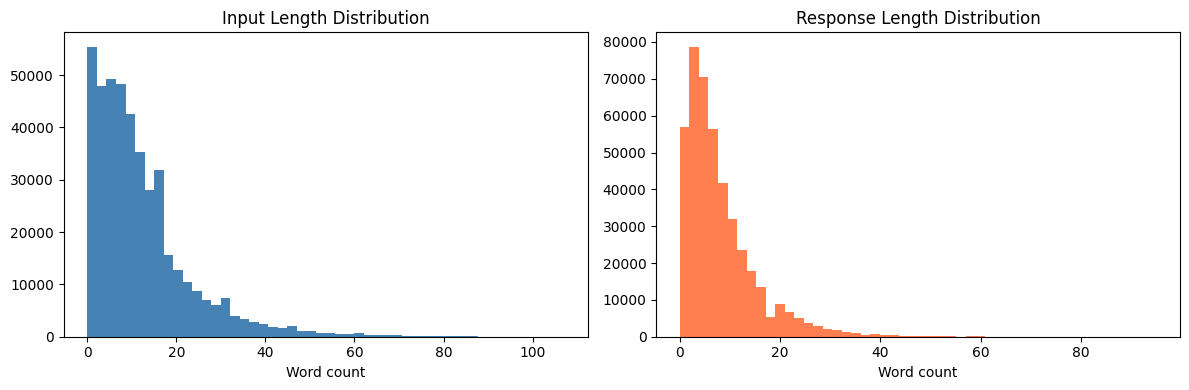

In [64]:
import matplotlib.pyplot as plt

pairs_df['input_len'] = pairs_df['input'].apply(lambda x: len(x.split()))
pairs_df['response_len'] = pairs_df['response'].apply(lambda x: len(x.split()))

print(pairs_df[['input_len', 'response_len']].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(pairs_df['input_len'], bins=50, color='steelblue')
plt.title('Input Length Distribution')
plt.xlabel('Word count')

plt.subplot(1, 2, 2)
plt.hist(pairs_df['response_len'], bins=50, color='coral')
plt.title('Response Length Distribution')
plt.xlabel('Word count')

plt.tight_layout()
plt.savefig('visualisations/1-dialogue-pair-text-lengths.png')
plt.show()

So:
- The **median** is 9 words for inputs, 6 words for responses (sequences are short and concise)
- The **75th percentile** is 16 words for inputs, 11 words for responses (most pairs are pretty short actually)
- The **maximum length** is 107 words for inputs, 95 words for responses (outliers can be trimmed)
- The **minimum length** is 0 (I'm not sure how these slipped through, we can drop them)

Let's say... 20 words for the maximum sequence length? This would cover over 75% of our data with minimal padding. We can keep the minimum length small, but certainly more than 0 to remove those pointless pairs. Let's say 2. A more performant/efficient approach would be to utilise dynamic padding (batch specific padding based on the longest sequence in the batch).

In [65]:
MIN_LENGTH = 2 # drop the short turns
MAX_LENGTH = 20 # trim the long ones

filtered_df = pairs_df[ # Using the new columns we added above
    (pairs_df['input_len'] >= MIN_LENGTH) &
    (pairs_df['response_len'] >= MIN_LENGTH) &
    (pairs_df['input_len'] <= MAX_LENGTH) &
    (pairs_df['response_len'] <= MAX_LENGTH)
].reset_index(drop=True)

# Now drop those columns as we don't want them around any longer
filtered_df = filtered_df.drop(columns=['input_len', 'response_len'])

print(f'Pairs before filtering: {len(pairs_df)}')
print(f'Pairs after filtering:  {len(filtered_df)}')
print(f'Retained: {len(filtered_df)/len(pairs_df)*100:.1f}%')
filtered_df.head(10)

Pairs before filtering: 433329
Pairs after filtering:  262514
Retained: 60.6%


,input,response
0,"also guys, i'm trying to get into my firefox preferences, but it keeps telling me 'root.disabled = 'true';",are you logged in as 'root' ?
1,ugh ;( seems to be broken ;(,"perhaps if you define *broken* a little, we can help."
2,"perhaps if you define *broken* a little, we can help.","hypa7ia: every single entry is by tollef fog heen, dated november 15th. all of those are old blog entries."
3,is so g-a-y,"easy, now"
4,"sorry, typo, ignore that... try this one bug 767085",so update libc6?
5,how do i get out of this annoying unity? i can't take this anymore,sudo apt-get install gnome-shell. unfortuately gnome-shell is pretty similar to unity but probably worse
6,but when i put the username and password for the xubuntu machine is still doesnt work,it sounds like samba configuration
7,hai thar,go awai
8,it would install anotehr bootloader,like what?
9,is there a way to do this remotely using remote access?,yes it is


We have ended up with ~260k samples in our dataset. We can work with that. Bear in mind we only started with a small fraction of the original dataset anyway!

As an aside, something I've noticed about these dialogue pairs is that some are not very coherent (see pair 9 above). These come from Ubuntu chat logs, so multiple concurrent conversations and threads involving many users is expected. We can't guarantee every turn responds in full to the previous one.

## Train/Validation/Test Splits

---

This portion of the preprocessing pipeline is usual: produce our dataset splits for training, validation and testing. Nothing special here, I'll use Scikit-Learn's `train_test_split` to do all the heavy lifting for a 80/10/10 split ratio. We don't need to stratify around any variable for this type of problem :)

In [66]:
from sklearn.model_selection import train_test_split

# Split the test set
train_val_df, test_df = train_test_split(filtered_df, test_size=0.1, random_state=42)

# Split the validation set
train_df, val_df = train_test_split(train_val_df, test_size=0.1, random_state=42)

print(f'Train:\t\t{len(train_df)} pairs ({len(train_df)/len(filtered_df)*100:.1f}%)')
print(f'Validation:\t{len(val_df)} pairs ({len(val_df)/len(filtered_df)*100:.1f}%)')
print(f'Test:\t\t{len(test_df)} pairs ({len(test_df)/len(filtered_df)*100:.1f}%)')

Train:		212635 pairs (81.0%)
Validation:	23627 pairs (9.0%)
Test:		26252 pairs (10.0%)


## Tokenisation and Vocabulary 

---

From here on out, everything should be familiar enough from the MMA: we need to tokenise our sequences and produce a vocabulary dictionary. To prevent data leakage, we want to build our vocabulary from the training set ONLY.

In [67]:
from collections import Counter

def tokenise(text):
    """
    Split on whitespace
    """
    return text.split()

counter = Counter()

for text in train_df['input']:
    counter.update(tokenise(text))
for text in train_df['response']:
    counter.update(tokenise(text))

print(f'Total unique tokens: {len(counter)}')
print(f'\nMost common tokens:\n{counter.most_common(40)}')
print(f'\nLeast common tokens (sample):\n{counter.most_common()[-40:]}')

Total unique tokens: 159738

Most common tokens:
[('i', 110875), ('the', 102711), ('to', 94980), ('a', 74178), ('is', 65005), ('you', 63155), ('it', 55245), ('in', 42954), ('and', 36689), ('for', 36630), ('can', 35654), ('how', 32694), ('that', 32557), ('do', 32350), ('on', 28414), ('what', 27429), ('have', 25742), ('of', 25696), ('ubuntu', 24363), ('with', 24057), ('not', 23276), ('my', 21140), ('but', 19076), ('install', 18953), ('there', 18339), ('use', 17884), ('or', 17750), ('if', 17140), ('just', 16962), ('?', 15709), ('are', 15566), ('anyone', 15021), ('be', 14925), ('know', 14180), ('me', 13820), ('your', 13414), ('from', 13199), ('does', 12638), ('try', 12424), ('get', 11989)]

Least common tokens (sample):
[('#sdl', 1), ("#sdl'", 1), ('ehad', 1), ('eventualities', 1), ('tahnks', 1), ('kinda..', 1), ('audalicious', 1), ('auth)', 1), ('#ntfs', 1), ('liscensing', 1), ('mrbass.org', 1), ('leechcraft,', 1), ('/your/disk/bin_or_somethin/update_grub', 1), ('#network', 1), ("clocks'?

That's a huge vocabulary! Likely many mispellings, random strings, there are even system paths scattered throughout. We need to reduce our vocabulary size. We can consider a minimum token frequency and aim for around 20k to 30k tokens in the vocabulary. This dataset likely contains lots of meaningful technical terms too. Let's see what threshold might work best:

In [68]:
for min_freq in [1, 2, 3, 5, 10]:
    vocab_size = sum(1 for _, count in counter.items() if count >= min_freq)
    print(f'min_freq={min_freq}: {vocab_size} tokens')

min_freq=1: 159738 tokens
min_freq=2: 58038 tokens
min_freq=3: 35764 tokens
min_freq=5: 22883 tokens
min_freq=10: 13208 tokens


5 seems good!

In [69]:
MIN_TOKEN_FREQ = 5

# Create the vocab dict and lets also reserve some special tokens for:
vocab = {
    '<PAD>': 0, # Padding
    '<SOS>': 1, # Start of sequence
    '<EOS>': 2, # End of sequence
    '<UNK>': 3 # Unknown token
}

# Let's add all tokens meeting the minimum frequency to reach our rough desired token count
for word, count in counter.items():
    if count >= MIN_TOKEN_FREQ: # Minimum token frequency
        vocab[word] = len(vocab) # Next available idx

# Reverse the dictionary
vocab_reversed = {idx: word for word, idx in vocab.items()}

print(f'Final vocabulary size: {len(vocab)}')

Final vocabulary size: 22887


## Encoding and Padding

---

We need to convert each pair input and response to fixed-length sequences. That will involve truncating or padding each.

In [70]:
import torch
from torch.nn.utils.rnn import pad_sequence

def encode_sequence(text, vocab, max_len):
    """
    Encode text into id sequences using the provided vocab dictionary. Truncate and pad.
    """
    tokens = tokenise(text)[:max_len] # Truncate to maximum sequence length
    vals = [vocab.get(t, vocab['<UNK>']) for t in tokens] # Get token, or default to 1
    remaining = max_len - len(vals)
    vals = vals + [vocab['<PAD>']] * remaining # Pad to the max length
    
    return vals

# Test on the first sample
sample_input = train_df['input'].iloc[0]
sample_response = train_df['response'].iloc[0]

print(f'Original input:   {sample_input}')
print(f'Encoded input:    {encode_sequence(sample_input, vocab, MAX_LENGTH)}')
print(f'\nOriginal response:  {sample_response}')
print(f'Encoded response:   {encode_sequence(sample_response, vocab, MAX_LENGTH)}')

Original input:   any ideas?
Encoded input:    [4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Original response:  try ekiga softphone, it comes with ubuntu
Encoded response:   [40, 2921, 3, 41, 1905, 25, 66, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Looks good. 'softphone' -> 3 (`<UNK>`) -> an example of a word not in our vocabulary, that isn't frequent enough in our training set to warrant a dedicated token.

## PyTorch Dataset and DataLoader

---

The PyTorch `Dataset` will contain our training/validation set, the `DataLoader` will wrap the `Dataset` and handle batching, shuffling, parallelising, etc.

Because we're building seq2seq models with an encoder _and_ decoder, we need each sample to be: `(encoder_input, decoder_input, decoder_target)`

- `encoder_input` — encoded input sequence
- `decoder_input` — encoded response with `<SOS>` prepended
- `decoder_target` — encoded response with `<EOS>` appended

At each step, the decoder will be predicting the next token. So along with the encoder's output hidden state (or hidden states for when we train our attention model), it also needs the encoded response as input to produce an output sequence. 

In [71]:
from torch.utils.data import Dataset, DataLoader

class DialogueDataset(Dataset):
    def __init__(self, pairs, vocab, max_len):
        self.pairs = pairs.reset_index(drop=True) # pairs is a DataFrame
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        input_text = self.pairs.loc[idx, 'input']
        response_text = self.pairs.loc[idx, 'response']

        # encoder_input: Encoded input sequence (for the encoder)
        encoder_input = encode_sequence(input_text, self.vocab, self.max_len)

        # Encoded response (used to construct decoder input and target)
        response_tokens = tokenise(response_text)[:self.max_len - 1] # Chop off a token to replace with either SOS or EOS
        encoded_response = [self.vocab.get(t, self.vocab['<UNK>']) for t in response_tokens]

        # decoder_input: Encoded response with <SOS> prepended (pad to the max length)
        decoder_input = [self.vocab['<SOS>']] + encoded_response
        remaining = self.max_len - len(decoder_input)
        decoder_input = decoder_input + [self.vocab['<PAD>']] * remaining

        # decoder_target: Encoded response with <EOS> appended (pad to the max length)
        decoder_target = encoded_response + [self.vocab['<EOS>']]
        decoder_target = decoder_target + [self.vocab['<PAD>']] * remaining

        return (
            torch.tensor(encoder_input, dtype=torch.long),
            torch.tensor(decoder_input, dtype=torch.long),
            torch.tensor(decoder_target, dtype=torch.long)
        )

# Lets create our PyTorch Datasets and DataLoaders!
train_dataset = DialogueDataset(train_df, vocab, MAX_LENGTH)
val_dataset = DialogueDataset(val_df, vocab, MAX_LENGTH)
test_dataset = DialogueDataset(test_df, vocab, MAX_LENGTH)

# Batch size of 64 seems appropriate
BATCH_SIZE = 64

# Shuffle to ensure all batches get a good representation of samples
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Verify a batch
enc_batch, dec_in_batch, dec_tgt_batch = next(iter(train_loader))
print(f'Encoder input batch shape:  {enc_batch.shape}')
print(f'Decoder input batch shape:  {dec_in_batch.shape}')
print(f'Decoder target batch shape: {dec_tgt_batch.shape}')

Encoder input batch shape:  torch.Size([64, 20])
Decoder input batch shape:  torch.Size([64, 20])
Decoder target batch shape: torch.Size([64, 20])


## Done! Save to File

---

Here, I'll persist the three datasets to a preprocessed folder. That way, any other notebooks in this project (see model-a.ipynb notebook for example) can load in the CSVs and crack on straight away with loading embeddings and model experimentation.

In [75]:
import json
import os

PREPROCESSED_DIR = './data/preprocessed'
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

# We'll save the dataset splits as CSVs
train_df.to_csv(f'{PREPROCESSED_DIR}/train.csv', index=False)
val_df.to_csv(f'{PREPROCESSED_DIR}/val.csv', index=False)
test_df.to_csv(f'{PREPROCESSED_DIR}/test.csv', index=False)

# And the vocabulary dictionaries as json files
with open('./data/preprocessed/vocab.json', 'w') as f:
    json.dump(vocab, f)

with open('./data/preprocessed/vocab_reversed.json', 'w') as f:
    json.dump(vocab_reversed, f)

# And finally a config dictionary 
config = {
    'MAX_LENGTH': MAX_LENGTH,
    'MIN_TOKEN_FREQ': MIN_TOKEN_FREQ,
    'MIN_LENGTH': MIN_LENGTH,
    'BATCH_SIZE': BATCH_SIZE,
    'VOCAB_SIZE': len(vocab),
    'PAD_IDX': vocab['<PAD>'],
    'SOS_IDX': vocab['<SOS>'],
    'EOS_IDX': vocab['<EOS>'],
    'UNK_IDX': vocab['<UNK>']
}
with open(f'{PREPROCESSED_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved to:')
print(f'\ttrain.csv, val.csv, test.csv ({len(train_df), len(val_df), len(test_df)} pairs)')
print(f'\tvocab.json, vocab_reversed.json ({len(vocab)} tokens)')
print(f'\tconfig.json')

Saved to:
	train.csv, val.csv, test.csv ((212635, 23627, 26252) pairs)
	vocab.json, vocab_reversed.json (22887 tokens)
	config.json
